<h4>定义 Определение</h4>

In [334]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import floor
import csv

<h4>在此定义输入维度和目标维度</h4>
需要将测试集里面的Very Low转化成very_low

In [335]:
type = {"very_low":0,"Low":1,"Middle":2,"High":3}#将类型变为数字 Преобразование типов в числа
name = ["very_low","Low","Middle","High"]#将数字变为类型 Преобразование чисел в типы
num_Target = len(name)
dim_Input = 5

<h4>读取文件并把向量数字化 Чтение файла и векторизация данных</h4>
需要依据情况修改sep

In [336]:
file = 'train.csv'
df = pd.read_csv(file, encoding='utf-8',sep=',')
array = df.to_numpy()
for j in range(len(array)):
    array[j][dim_Input] = type[array[j][dim_Input]]

file = 'test.csv'
df = pd.read_csv(file, encoding='utf-8',sep=',')
arrayTest = df.to_numpy()
for j in range(len(arrayTest)):
    arrayTest[j][dim_Input] = type[arrayTest[j][dim_Input]]

<h4>提取初始以及目标向量 Извлечение начальных и целевых векторов</h4>

In [337]:
X = array[:, :dim_Input]
Y = array[:, dim_Input]
Y=Y.astype(np.int64)
X_test = arrayTest[:, :dim_Input]
Y_test = arrayTest[:, dim_Input]
num_INP = len(array)
probability = []#将类型转化为概率
num_INP = len(array)
matrixTarget = np.eye(num_Target)
for i in range(num_INP):
    probability.append(matrixTarget[Y[i]])

#归一化
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X = (X - X_min) / (X_max - X_min + 1e-8)
X_test = (X_test - X_min) / (X_max - X_min + 1e-8)

<h4>在下面定义近邻数K≤len(X) </h4>

In [338]:
K=5
if K>len(X):
    K=int(len(X)/2)
print(K)

5


<h4>训练及模型 Обучение и модель</h4>

In [339]:
def sumNorm2(inpVec):#在欧几里得空间计算范数平方
    norm = []
    for i in range(len(X)):
        norm.append(np.sum((inpVec-X[i])**2))
    return norm

def distMan(inpVec):
    norm = []
    for i in range(len(X)):
        norm.append(np.sum(abs(inpVec-X[i])))
    return norm

def sortK(inpvec,Kinp):#返回前K小的索引以及距离
    inpvec=np.array(inpvec)
    sorted_idx = np.argsort(inpvec)
    result = inpvec[sorted_idx]
    return result[:Kinp], sorted_idx[:Kinp]

def prediction(inpMat,Kinp):
    lenn = len(inpMat)
    probab = np.zeros((lenn,num_Target))
    predictResult = []
    for i in range(lenn):
        #nearistNorm, nearistIdx = sortK(sumNorm2(inpMat[i]))#欧几里得
        nearistNorm, nearistIdx = sortK(distMan(inpMat[i]),Kinp)#曼哈顿
        weigh = 1 / (nearistNorm + 1e-8)
        counted = np.bincount(Y[nearistIdx], weights=weigh, minlength=num_Target)
        probab[i] = counted/Kinp
        predictResult.append(np.argmax(probab[i]))
    return probab, predictResult
        
probabMat, predicted = prediction(X_test,K)

<h4>测试模型 Тест Моделя</h4>

In [340]:
errorCount = 0
lenTest = len(Y_test)
for i in range(lenTest):
    if(predicted[i] != Y_test[i]):
        errorCount += 1
accuracy = (lenTest-errorCount)/lenTest
print(accuracy)
print(errorCount)

0.8689655172413793
19


<h4>寻找最优K(对于特定测试集)</h4>
似乎对于离散数组不太好用

In [341]:
epsilon = 0.1#当准确率变化率小于该值时停止循环
dNerr = 10
Kvar = K
Nmax = 100
i=0
while dNerr > epsilon and (Kvar>2 and Kvar <len(X)-1):
    probabMat1, predicted1 = prediction(X_test,Kvar)
    probabMat2, predicted2 = prediction(X_test,Kvar+1)
    errorCount1 = 0
    errorCount2 = 0
    for i in range(lenTest):
        if(predicted1[i] != Y_test[i]):
            errorCount1 += 1
        if(predicted2[i] != Y_test[i]):
            errorCount2 += 1
    dNerr = errorCount1-errorCount2
    Kvar += -int(dNerr/(abs(dNerr+1E-8)))
    i+=1
    if(i>Nmax):
        break
    
print(Kvar)

5


<h4>绘制N(K)</h4>

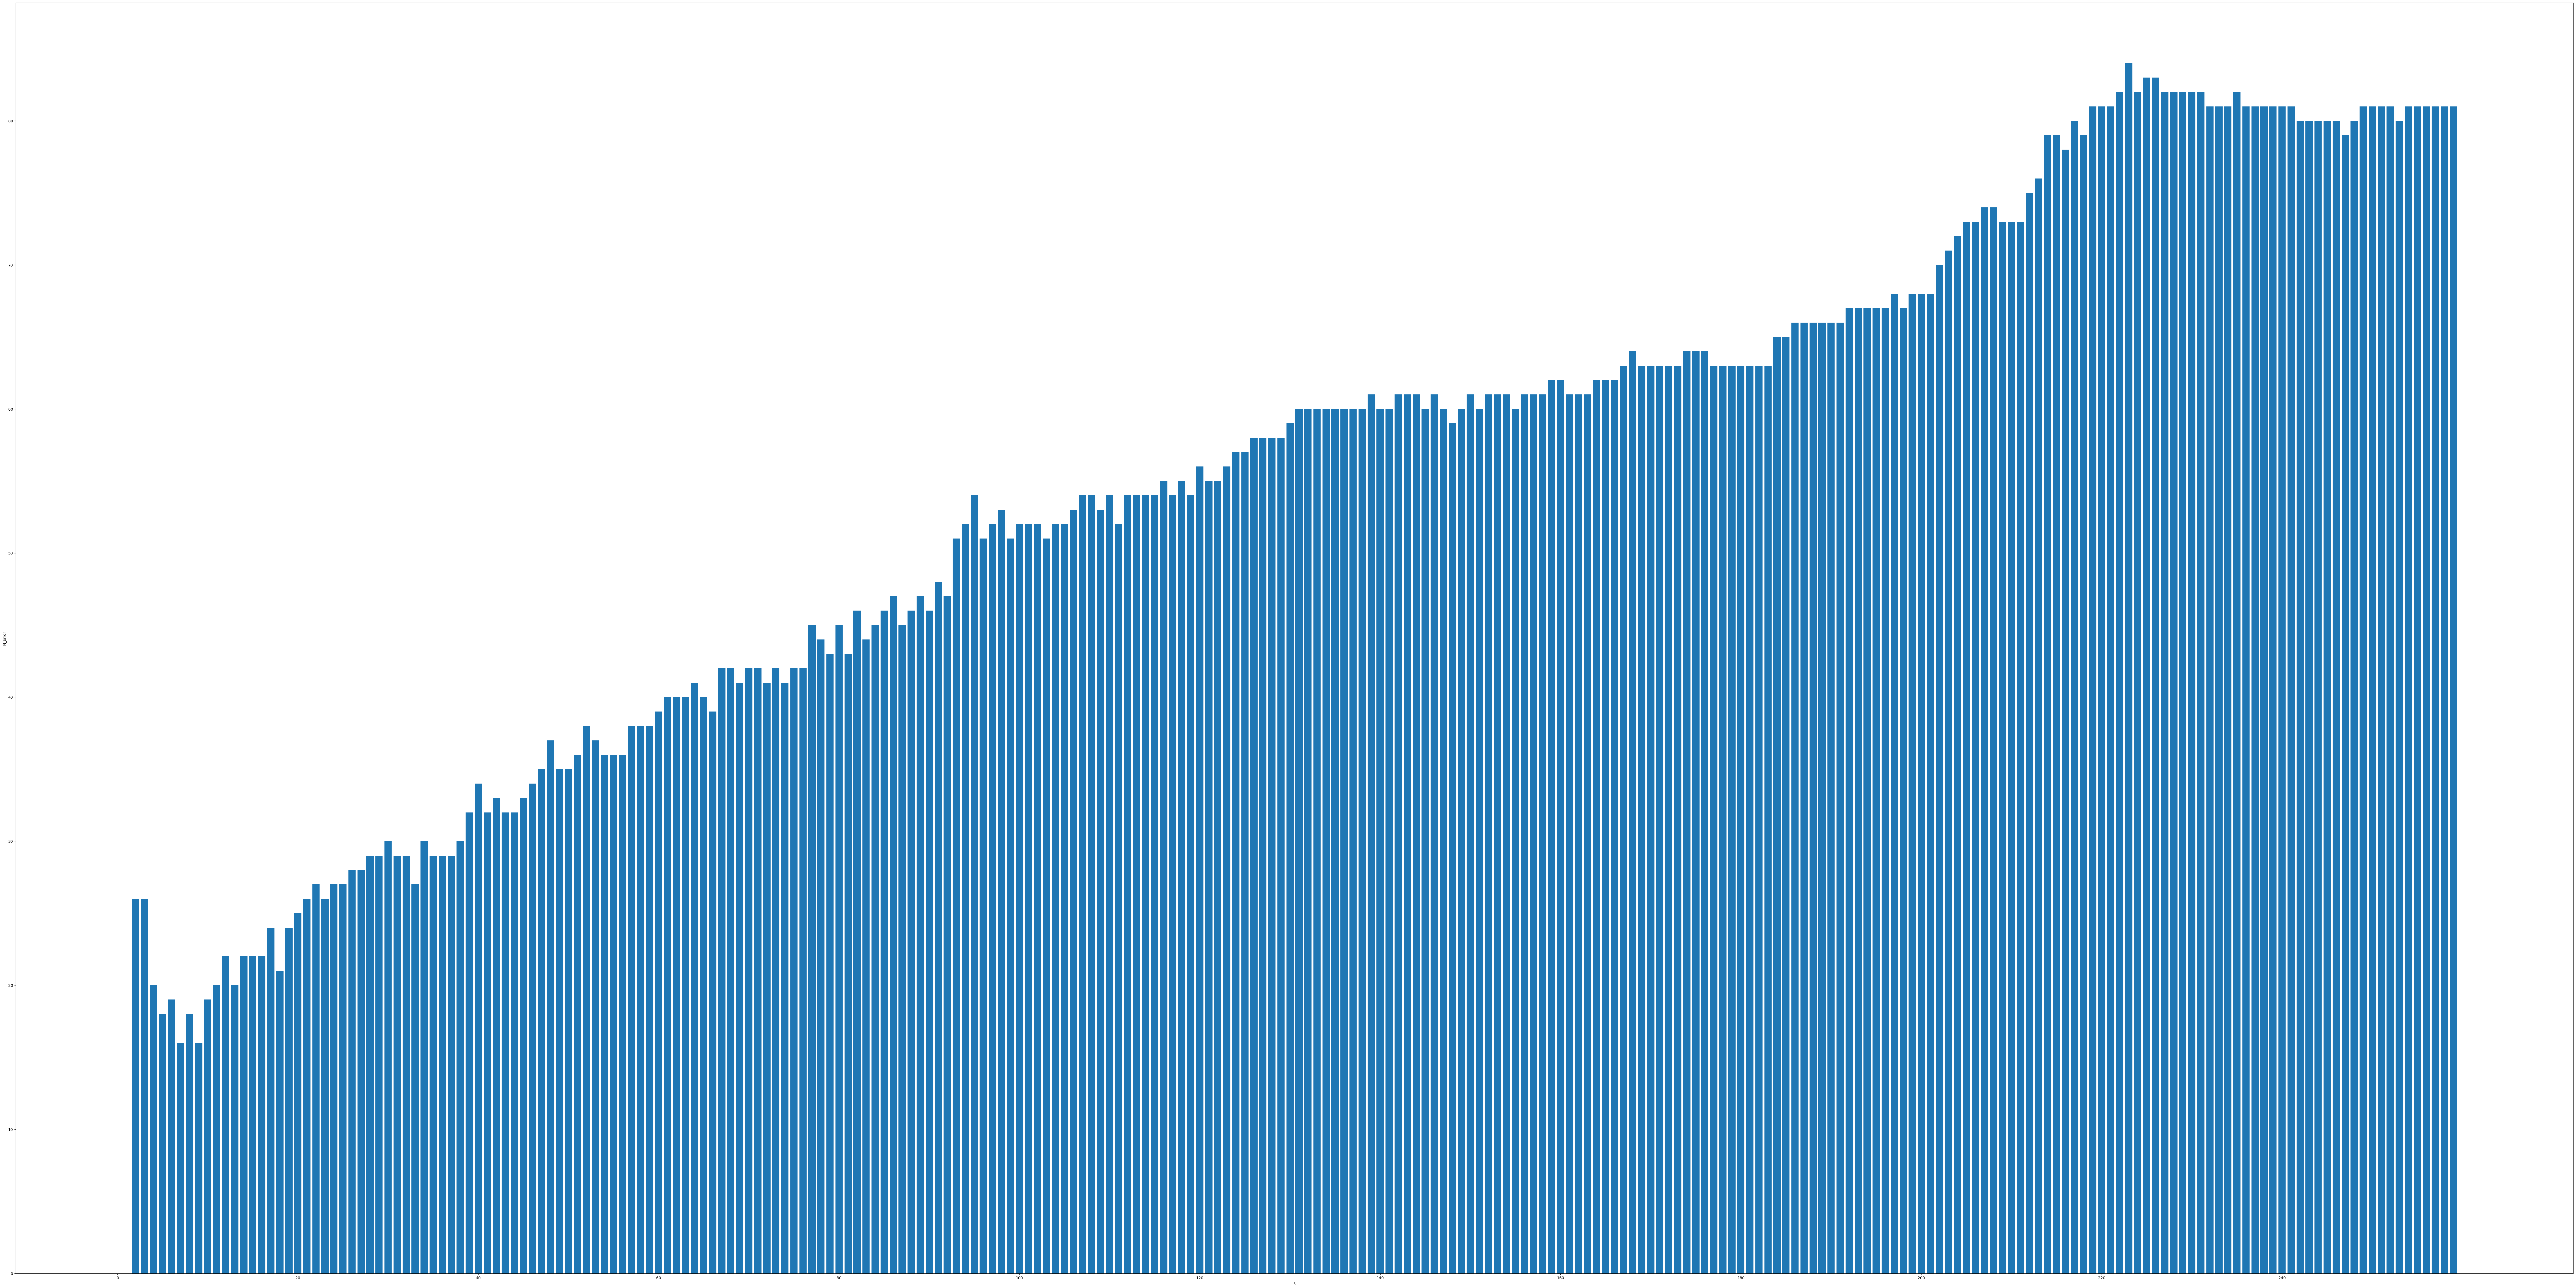

[16] [5]


In [342]:
Kvar = 1
kList = []
NList = []
for i in range(len(X)):
#for i in range(20):
    errorCount = 0
    probabMat, predicted = prediction(X_test,Kvar)
    for j in range(lenTest):
        if(predicted[j] != Y_test[j]):
            errorCount += 1
    Kvar += 1
    kList.append(Kvar)
    NList.append(errorCount)
xtickss= np.arange(0, kList[-1] + 1, 20)
plt.figure(figsize=(120, 60))
plt.bar(kList, NList, width=0.8)  # width 控制柱子宽度
plt.xticks(xtickss)
plt.xlabel('K')
plt.ylabel('N_Error')
plt.show()

minN, minIdx=sortK(NList,1)
print(minN,minIdx)